In [1]:
import numpy as np

import ngsolve 
from ngsolve.webgui import Draw
import netgen.geom2d

import matplotlib.pyplot as plt
import matplotlib.tri as tri
import copy
import importlib
import pickle
%matplotlib inline

notebookroot = 'Circ_v003'  # for output file names

import bio_mem_helpers   # helper routines


In [3]:
importlib.reload(bio_mem_helpers)  # if you are working on the helper routines 

<module 'bio_mem_helpers' from '/Users/aquillen/Desktop/summer25/pylab/bio_fem2/bio_mem_helpers.py'>

In [2]:
# parameters for this run 

mu = 1.0; lam = 20; pi_k = 0.1;  dt = 0.04  # shear modulus, Lame parameter, damping parameter timestep
p0=0.5; AA = 3.0;  # parameters for non-linear op
# lam is actually lambda/mu = (B-mu)/mu

tend= 80.0; scount = int(0.5/dt) # scount is frequency of outputs and redraws, tend is final time of integration 

parmlabel = ""
parmlabel += r'$A$={:.0f}'.format(AA)
parmlabel +=','
parmlabel += r'$\pi_k$={:.1f}'.format(pi_k)
parmlabel +=','
parmlabel += r'$\pi_\lambda$={:.0f}'.format(lam)
parmlabel +=','
parmlabel += r'$p_*$={:.1f}'.format(p0)
parmlabel +=',D'
print(parmlabel)

sim_parms = bio_mem_helpers.sim_stuff(mu,lam,pi_k,dt,p0,AA,scount,parmlabel)

$A$=3,$\pi_k$=0.1,$\pi_\lambda$=20,$p_*$=0.5,D


### Dirichlet circle no noise

In [3]:
# generate a 2d triangular mesh in a shaped domain
# https://docu.ngsolve.org/latest/i-tutorials/unit-4.1.2-csg2d/csg2d.html
# run this even if you have saved the run, we need the mesh  
geo = netgen.geom2d.CSG2d()

fac = 50  # rescaling factor 
#yratio = 1.0

# make a circle 
circle1 = netgen.geom2d.Circle( center=(0,0), radius=1.0*fac,  bc="outer" )

all_boundaries = 'outer'
d_boundaries = 'outer' #   # dirichlet
n_boundaries = ''  # neumann BC

subs =  circle1 
geo.Add(subs)

# generate the mesh
maxh_mesh = 0.04*fac  # max distance between nodes?
mesh = ngsolve.Mesh(geo.GenerateMesh(maxh=maxh_mesh))  # maxh here sets the scale of elements 
print(f"vertices={mesh.nv}, edges ={mesh.ne}")  # print numbers of vertices and edges!

# create finite element system 'fes'  only for displacement field u
korder = 3
Q1 = ngsolve.VectorH1(mesh, order=korder,dirichlet=d_boundaries) 
# Choose an element that is in the Sobolev space H1, first 2d field
fes = Q1   # our finite element space is  a 2d vector space 

Draw(mesh) # show the mesh

print(mesh.GetBoundaries())


vertices=2395, edges =4632


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

('outer', 'outer', 'outer', 'outer')


In [ ]:
# finally we get to run stuff!
# lam is actually lambda/mu = (B-mu)/mu

mu, lam, pi_k, dt, p0, AA, scount, parmlabel = sim_parms.ret_info()  # read in parameters

#mu = 1.0; lam = 20; pi_k = 0.1;  dt = 0.04  # shear modulus, Lame parm, damping parm, timestep
sp_fun,f,invm,a,invastar = bio_mem_helpers.mkops_u(fes,mu,lam,pi_k,dt)  # create linear and bilinear forms

sig=0.1;  alpha=0.1  # for initial conditions, parms control noises,  nearly white
# noise is set to be weaker in p
# if div0=False then  p(k) propto k^-alpha   if alpha small then is white noise 
gfu = bio_mem_helpers.mkinit_pink(fes,sig,alpha,div0=False)  # make initial conditions for u, p
gfp = bio_mem_helpers.mkinit_pink(fes,sig/100,alpha,div0=False)  # make initial conditions for u, p

gfu_vel = ngsolve.GridFunction(fes)  # place holder for velocity field 
gfu_vel.Set((0.0,0.0))
gfu_list=[]; gfp_list=[]; gfv_list=[]

# scene showing vector fields,  displacement field 
scene = Draw(gfu,mesh, settings = {  \
    "Colormap" : { "ncolors" : 20 },"Objects" : {"Wireframe" : False, "Vectors" : True, "Surface" : False} , \
    "Vectors"  : {"grid_size" :50} });   

#p0=0.5; AA = 3.0;  # parameters for non-linear op
tend= 80.0; #scount = int(0.5/dt) # scount is frequency of outputs and redraws, tend is final time of integration 

# run the simulation! gfu_list will store a bunch of velocity grid functions
gfu_list,gfp_list,gfv_list = bio_mem_helpers.time_stepping(fes,gfu,gfp,gfu_vel,sp_fun,f,invm,a,invastar,dt,AA,p0,scene,\
                                           t0=0,tend=tend,scount=scount,Wnoise=None,alphanoise=0.1,\
                                                           gfu_list=gfu_list,gfp_list=gfp_list,gfv_list=gfv_list)
timevec =  bio_mem_helpers.mktimevec(len(gfu_list),scount,dt)

In [5]:
# we can add onto it and integrate longer if we want to
tend = 220  # to 300 total
gfu_list,gfp_list,gfv_list = bio_mem_helpers.time_stepping(fes,gfu,gfp,gfu_vel,sp_fun,f,invm,a,invastar,dt,AA,p0,scene,\
                         t0=0,tend=tend,scount=scount,gfu_list=gfu_list,gfp_list=gfp_list,gfv_list=gfv_list,Wnoise=None,alphanoise=0.1)

timevec =  bio_mem_helpers.mktimevec(len(gfu_list),scount,dt)
print(' ',np.max(timevec))

 219.95999999999052  300.48


In [6]:
# save the run so we don't need to rerun the simulation!

# see https://docu.ngsolve.org/latest/i-tutorials/appendix-pickling/pickling.html
save_data = 0  # was saved 
if (save_data ==1):
    ofilename = notebookroot + "gfus.pkl"
    outfile = open(ofilename, "wb")
    print(ofilename)
    pickle.dump([gfu_list,gfp_list,gfv_list,gfu,gfp,gfu_vel,sim_parms], outfile)
    print(len(gfu_list))
    outfile.close()
    

Circ_v003gfus.pkl
626


In [4]:
# if you have already saved the simulation, then read it back in here!
load_data = 1 
if (load_data ==1): 
    ofilename = notebookroot + "gfus.pkl"
    infile = open(ofilename, "rb")
    print(ofilename)
    gfu_list,gfp_list,gfv_list,gfu,gfp,gfu_vel,sim_parms = pickle.load(infile)
    print(len(gfu_list))
    timevec =  bio_mem_helpers.mktimevec(len(gfu_list),scount,dt)
    mu,lam,pi_k,dt,p0,AA,scount,parmlabel = sim_parms.ret_info()  # restore simulation parameters!
    infile.close()

Circ_v003gfus.pkl
626


In [5]:
coarsemesh = ngsolve.Mesh(geo.GenerateMesh(maxh=maxh_mesh*2))  # maxh here sets the scale of elements 

Circ_v003_tryvel_104.png


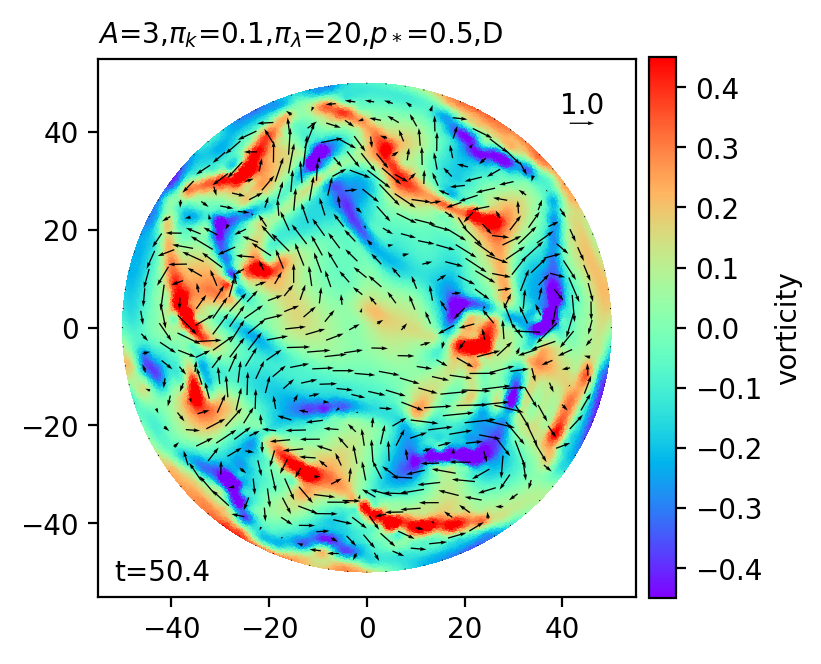

Circ_v003_tryvel_208.png


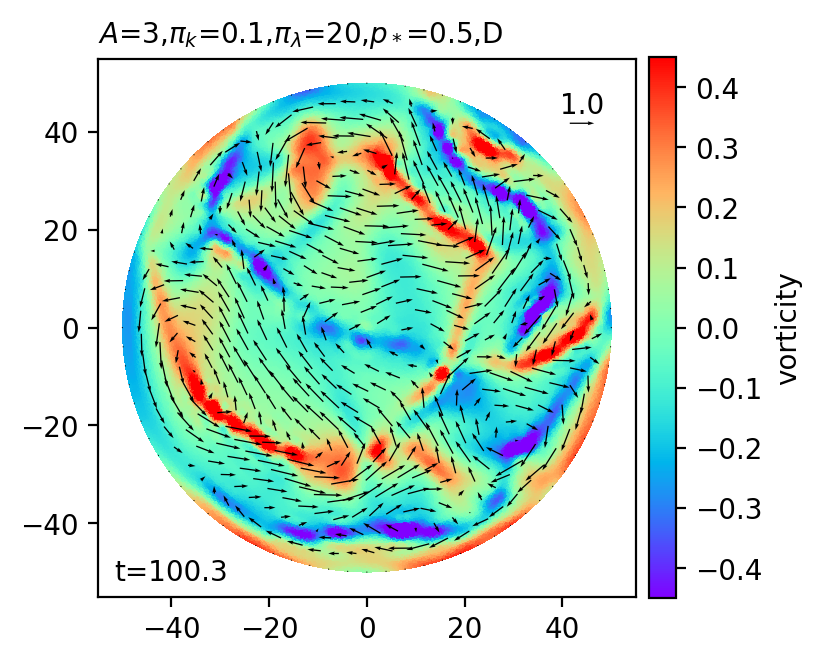

Circ_v003_tryvel_412.png


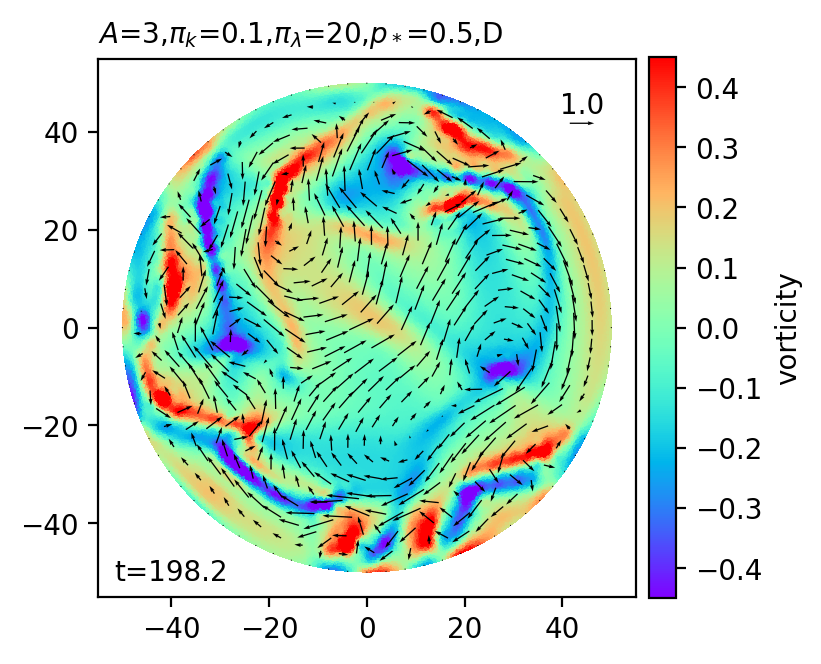

Circ_v003_tryvel_625.png


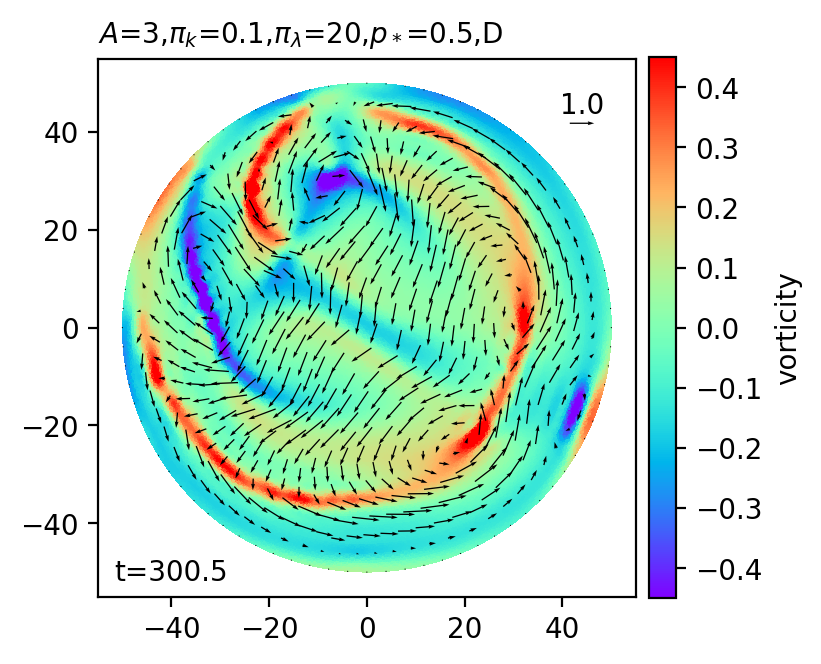

In [6]:

klist = [104,208,412,625]
# test so you can adjust the images 
for k in klist:

    root =  notebookroot+'_tryvel_'
    ofile = bio_mem_helpers.mkpngname(root,k)

    time = timevec[k]
    time_label = 't={:.1f}'.format(time)

    pl = parmlabel
    #if k >105:
    #    pl = ''
        
    #print(ofile)
    bio_mem_helpers.vorplot(gfv_list[k],mesh,coarsemesh,dt,time_label,ofile,vecscale=0.2,vlength_set=1,\
                            parmlabel=pl,cbar_shrink=0.80,cbar_label='vorticity',figy=0.95,vmaxx=0.45)
    plt.close('all')
   
    #bio_mem_helpers.vorplot(gfu_vel,mesh,coarsemesh,dt,time_label,ofile,vecscale=0.2,vlength_set=1,parmlabel=parmlabel,cbar_shrink=0.70)

Circ_v003_trydisp104.png


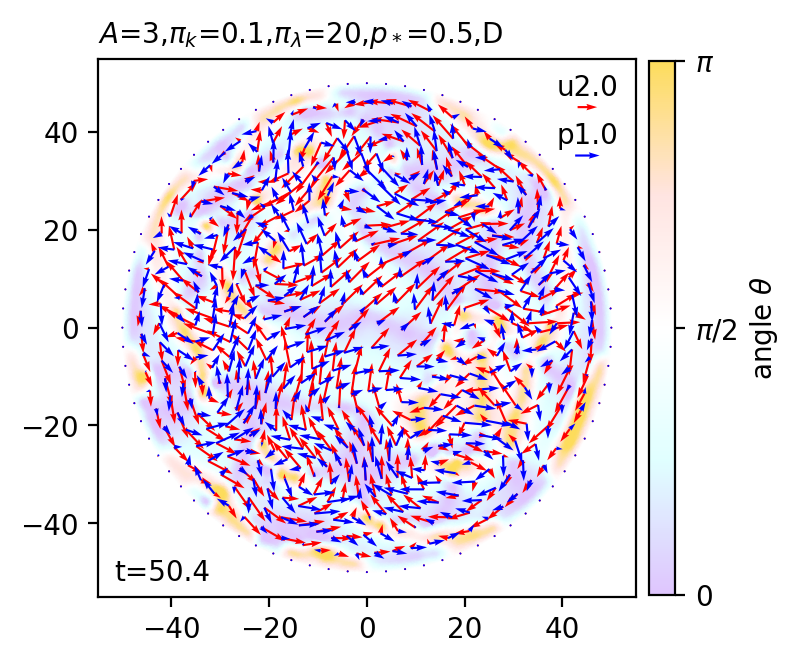

Circ_v003_trydisp208.png


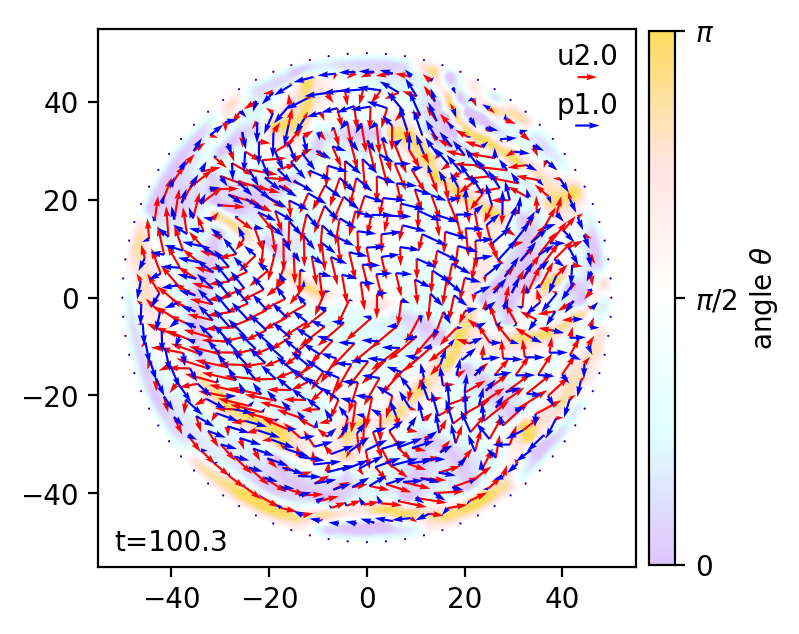

Circ_v003_trydisp412.png


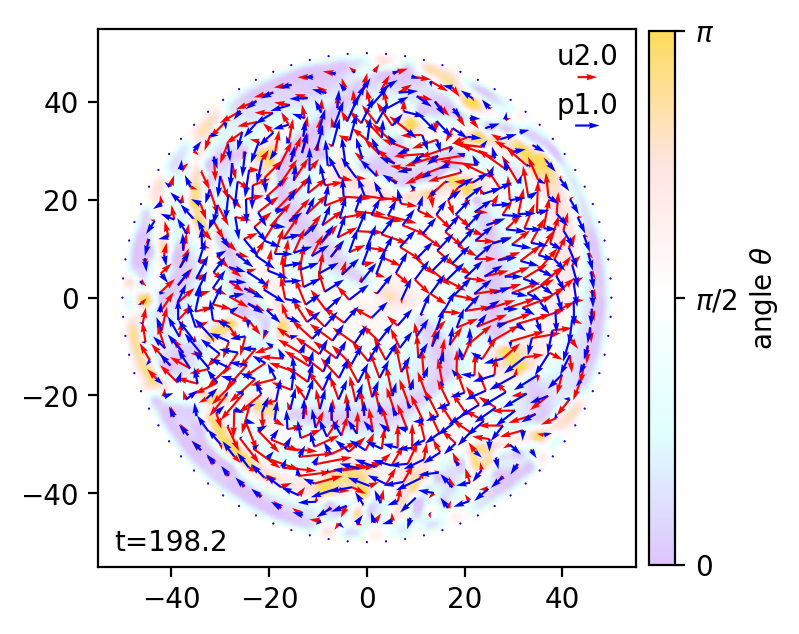

Circ_v003_trydisp625.png


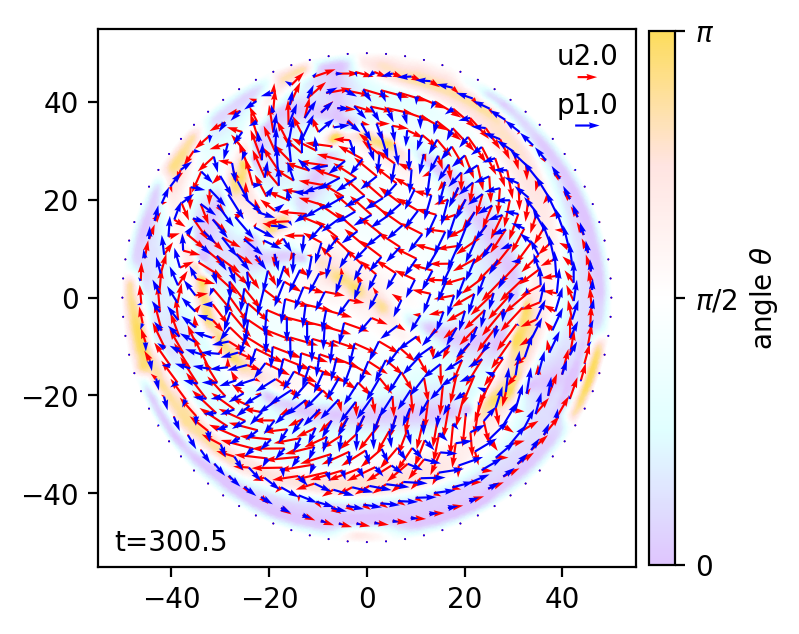

In [11]:
#importlib.reload(bio_mem_helpers)  # if you are working on the helper routines 
# show displacement and polarization vectors together 

klist = [104,208,412,625]
if (1==1):# not a test
    #coarsemesh = ngsolve.Mesh(geo.GenerateMesh(maxh=maxh_mesh*2))  # maxh here sets the scale of elements 
    root =  notebookroot+'_trydisp'
    for k in klist:
        #for k in range(len(timevec)):
        ofile = bio_mem_helpers.mkpngname(root,k)
        time = timevec[k]
        tlabel = 't={:.1f}'.format(time)
        pl=''
        if (k < 105):
            pl = parmlabel
        bio_mem_helpers.displot(gfu_list[k],gfp_list[k],mesh,coarsemesh,tlabel,ofile,plt_dotprod=True,\
                    vecscale_u=0.5, vlength_set_u = 2, vecscale_p = 0.2,vlength_set_p = 1,yratio=1,cbar_shrink=0.75,\
                               parmlabel=pl,cbar_label=r'angle $\theta$')
        plt.close('all')

Circ_v003_trycross104.png


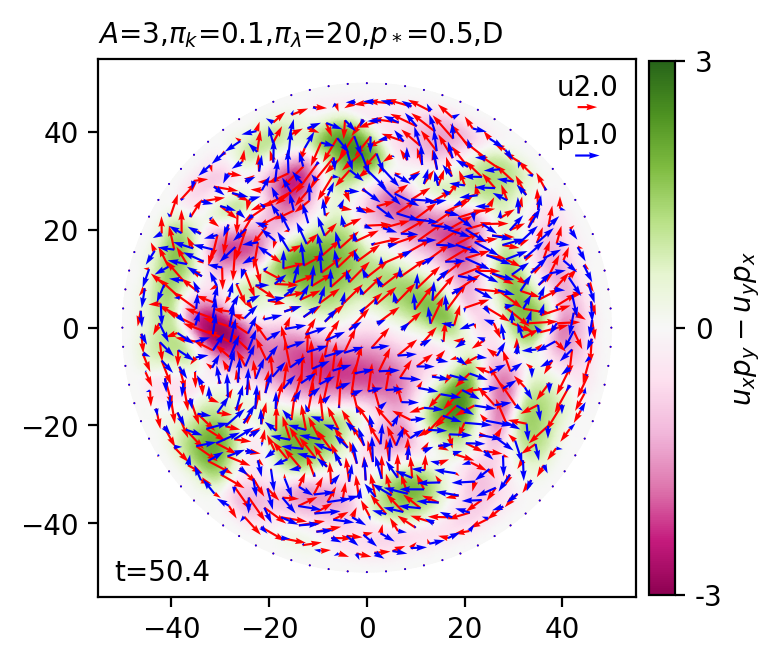

Circ_v003_trycross208.png


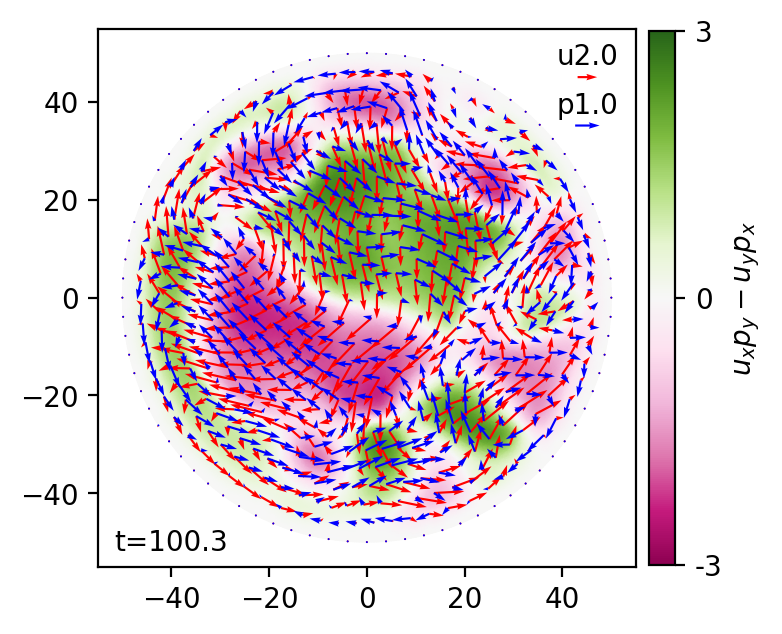

Circ_v003_trycross412.png


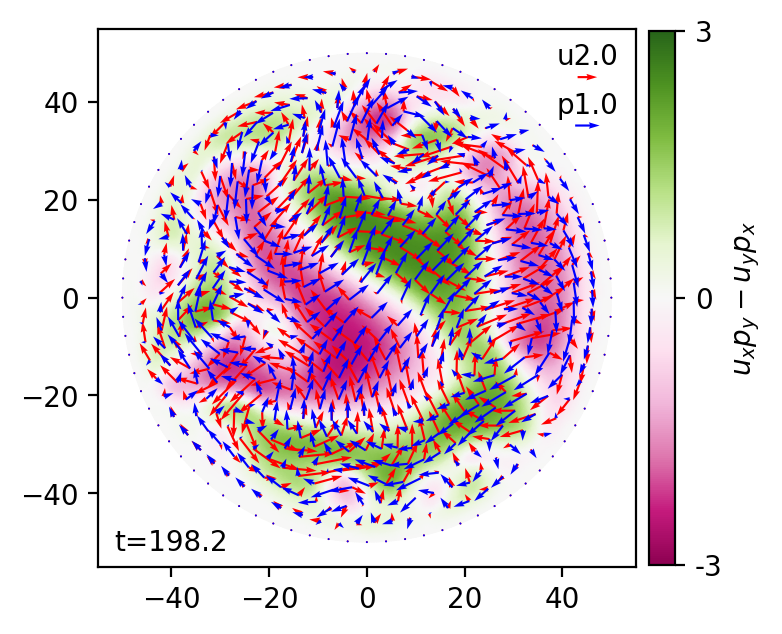

Circ_v003_trycross625.png


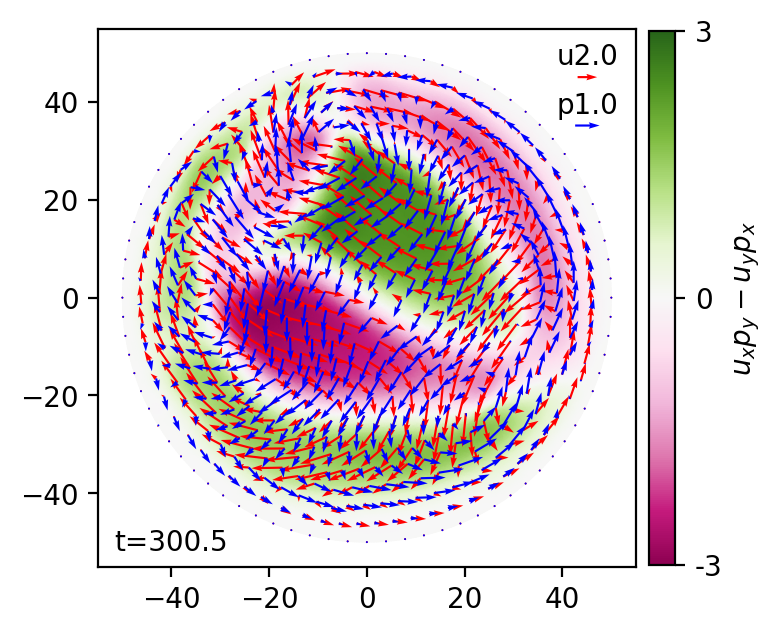

In [7]:
# show displacement and polarization vectors together 
importlib.reload(bio_mem_helpers) 

klist = [104,208,412,625]
if (1==1):# not a test
    root =  notebookroot+'_trycross'
    for k in klist:
        ofile = bio_mem_helpers.mkpngname(root,k)
        #print(ofile)
        time = timevec[k]
        tlabel = 't={:.1f}'.format(time)
        pl = ''
        if (k < 105):
            pl = parmlabel
        bio_mem_helpers.displot(gfu_list[k],gfp_list[k],mesh,coarsemesh,tlabel,ofile,plt_crossprod=True,\
            vecscale_u=0.5, vlength_set_u = 2, vecscale_p = 0.2,vlength_set_p = 1,yratio=1,cbar_shrink=0.75, \
                                    parmlabel=pl,cbar_label=r'$u_x p_y - u_y p_x$')
plt.close('all')

In [ ]:
# make a bunch of pngs from simulation output for movies 
root =  notebookroot+'_vel_'

for k in range(3,len(gfu_list)):

    gfv_temp = gfv_list[k]
    ofile = bio_mem_helpers.mkpngname(root,k)
    time = timevec[k]
    time_label = 't={:.1f}'.format(time)
    if (k <10):
        bio_mem_helpers.vorplot(gfv_temp,mesh,coarsemesh,dt,time_label,ofile,vecscale=0.2,vlength_set=1,cbar_shrink=0.80,\
                                parmlabel=parmlabel,cbar_label='vorticity',figy=0.95)
    else:
        bio_mem_helpers.vorplot(gfv_temp,mesh,coarsemesh,dt,time_label,ofile,vecscale=0.2,vlength_set=1,vmaxx=0.5,cbar_shrink=0.80,\
                               figy=0.95)
    if (k%10 == 0):
            plt.close('all')

In [ ]:
if (1==1):# not a test

    root =  notebookroot+'_disp'
    for k in range(3,len(timevec)):
        ofile = bio_mem_helpers.mkpngname(root,k)
        time = timevec[k]
        tlabel = 't={:.1f}'.format(time)
        if (k <10):
            bio_mem_helpers.displot(gfu_list[k],gfp_list[k],mesh,coarsemesh,tlabel,ofile,plt_dotprod=True,\
                    vecscale_u=0.5, vlength_set_u = 2, vecscale_p = 0.2,vlength_set_p = 1,yratio=1,cbar_shrink=0.80,\
                                   parmlabel=parmlabel,cbar_label=r'angle $\theta$')
        else:
            bio_mem_helpers.displot(gfu_list[k],gfp_list[k],mesh,coarsemesh,tlabel,ofile,plt_dotprod=True,\
                    vecscale_u=0.5, vlength_set_u = 2, vecscale_p = 0.2,vlength_set_p = 1,yratio=1,cbar_shrink=0.80)

        if (k%10 == 0):
            plt.close('all')

In [ ]:
if (1==1):# not a test

    root =  notebookroot+'_cross'
    for k in range(3,len(timevec)):
        ofile = bio_mem_helpers.mkpngname(root,k)
        time = timevec[k]
        tlabel = 't={:.1f}'.format(time)
        if (k <10):
            bio_mem_helpers.displot(gfu_list[k],gfp_list[k],mesh,coarsemesh,tlabel,ofile,plt_crossprod=True,\
                    vecscale_u=0.5, vlength_set_u = 2, vecscale_p = 0.2,vlength_set_p = 1,yratio=1,cbar_shrink=0.75,\
                                   parmlabel=parmlabel,cbar_label=r'$u_x p_y - u_y p_x$')
        else:
            bio_mem_helpers.displot(gfu_list[k],gfp_list[k],mesh,coarsemesh,tlabel,ofile,plt_crossprod=True,\
                    vecscale_u=0.5, vlength_set_u = 2, vecscale_p = 0.2,vlength_set_p = 1,yratio=1,cbar_shrink=0.75)

        if (k%10 == 0):
            plt.close('all')


Circ_v003_mesh.png


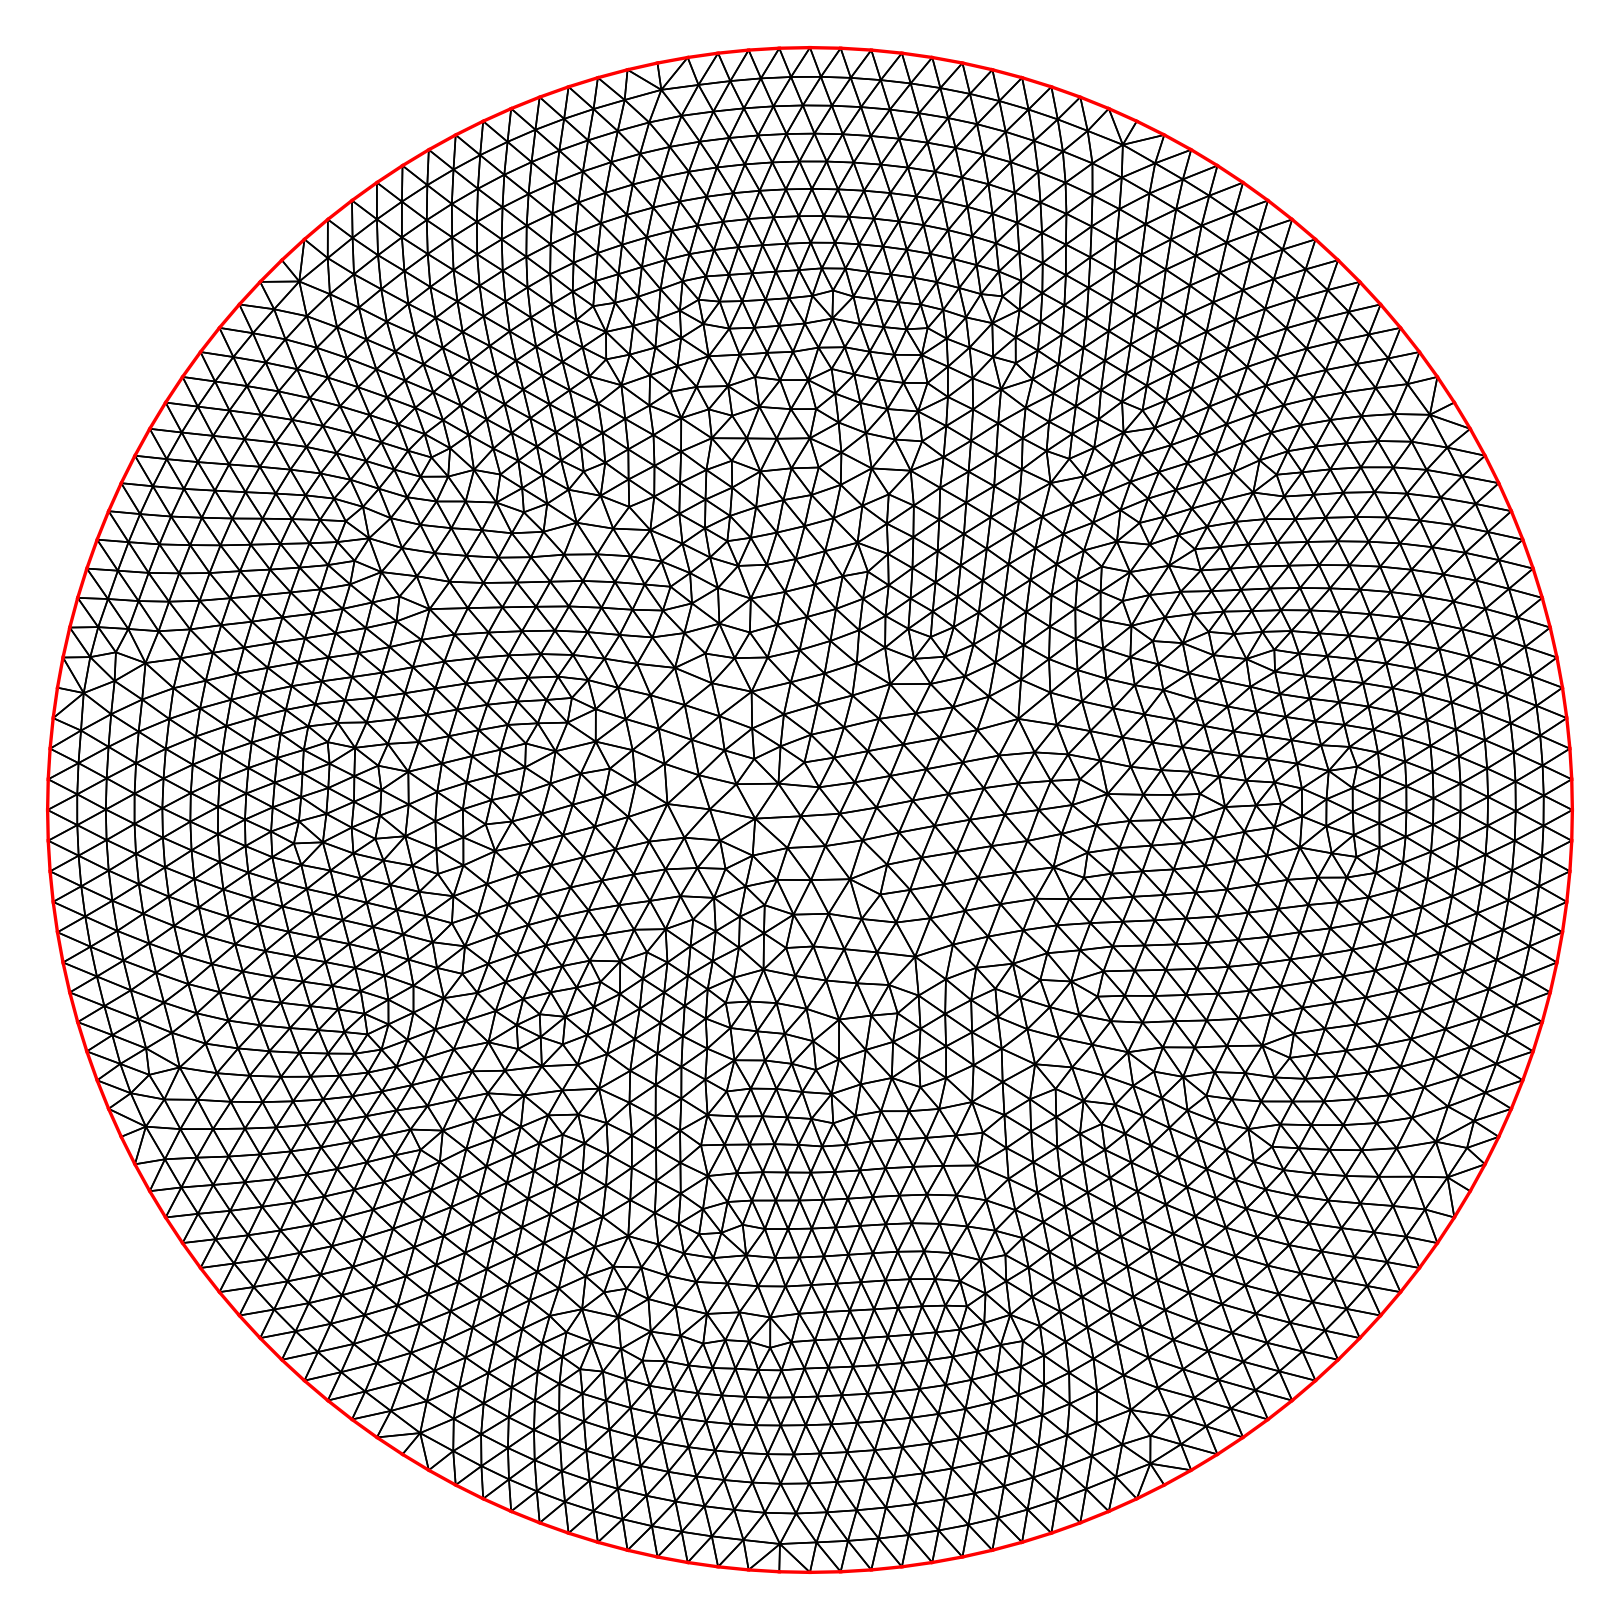

In [12]:
#importlib.reload(bio_mem_helpers)  # if you are working on the helper routines 
# show the mesh  
if (1==1):
    ofile = notebookroot + '_mesh.png'
    print(ofile)
    #n_boundaries = 'outer'
    bio_mem_helpers.draw_mesh(mesh,d_boundaries,ofile,n_boundaries=n_boundaries)
    